In [1]:

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

In [2]:

INPUT_PATH = "/content/dog.jpg"   # change this to your image filename
OUT_DIR = "augmented_output"
N_OUTPUTS = 10

os.makedirs(OUT_DIR, exist_ok=True)


In [4]:

# set up augmentation pipeline
datagen = ImageDataGenerator(
    rotation_range=30,       # rorate to 30 degrees
    width_shift_range=0.1,   # along width shifting of image
    height_shift_range=0.1,  # along height shifting of image
    shear_range=0.2,         # either veritcal or horizaontal
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode="nearest"      # empty spaces will be fill with near pixel value
)

In [5]:
# load and preprocess image
img = load_img(INPUT_PATH)           # PIL image
x = img_to_array(img)                # numpy array (H, W, C)
x = np.expand_dims(x, axis=0)        # shape (1, H, W, C)

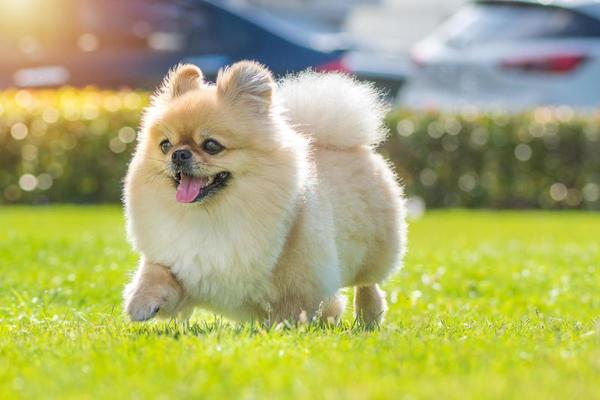

In [6]:
img

In [7]:

# generate and save augmented images
i = 0
for batch in datagen.flow(x,
                          batch_size=1, # at a time one image only will be generated
                          save_to_dir=OUT_DIR,
                          save_prefix="aug",
                          save_format="png"):
    if i >= N_OUTPUTS:
        break  # stop after 10 images
    i += 1

print(f"Saved {N_OUTPUTS} augmented images in {OUT_DIR}/")


Saved 10 augmented images in augmented_output/


IndexError: list index out of range

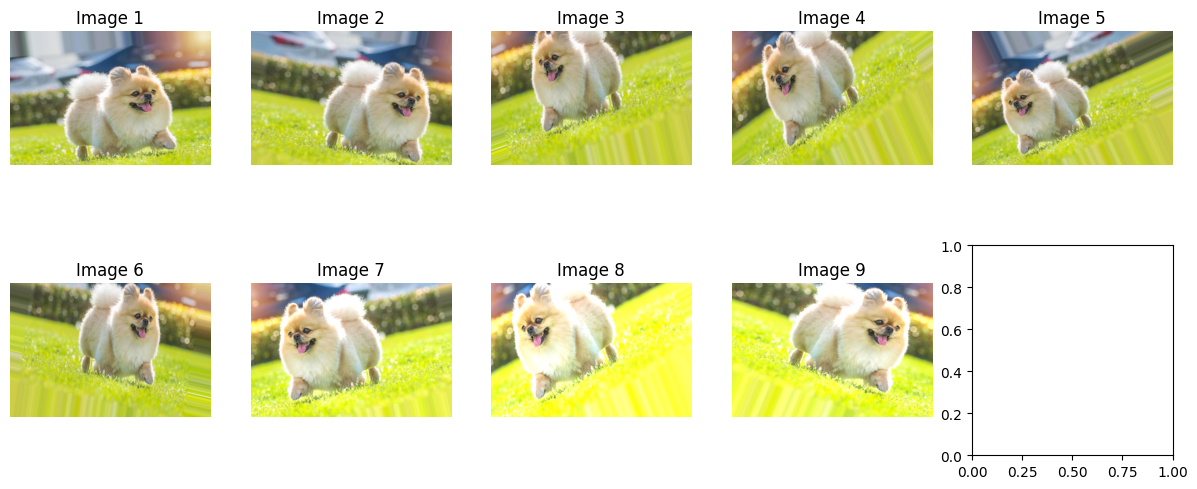

In [8]:
# plot them in a 2x5 grid
import matplotlib.pyplot as plt
images=[load_img(os.path.join(OUT_DIR, f)) for f in os.listdir(OUT_DIR)]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
    ax.set_title(f"Image {i+1}")

plt.tight_layout()
plt.show()